# Lab Exercise [30 Marks]

### <font color='red'>Deadline: 6<sup>th</sup> June 2026 (Saturday), 2.00pm.</font>

## Submission Instructions

- Download and rename this notebook according to your tutorial session and group number, e.g.: `LabEx_TTXL_GXX.ipynb`.
- Fill in all group members' details in the following Markdown cell.
- Fill in every group member's contribution in percentage, with the total 100%. All the members MUST AGREE to the percentages before submission. For example, the group members agree to give 0% contribution to the sleeping group member. 
- Not all group members in the same group will get the same mark. Your mark is depending on your contribution to the group work.
- Complete all the questions. Fill in your ANSWERS IN THIS NOTEBOOK.
- Submit this <b> .ipynb file </b> according to your registered group  in EbWise . Name your submission file as `LabEx_TTXL_GXX.ipynb`.
- Ensure that your notebook runs without errors on the examiner’s machine using the provided data file. Any cell that does not execute successfully in this environment will receive zero marks.


## Penalties
- For submission that does not conform to <i> Submission Instructions </i>, <b> 5 marks will be deducted </b>. 
- For submission <i> after the Deadline </i>, late submission penalty is applied with a deduction of <b> 1 mark per minute </b>. 

#### Group__

**Tutorial section: TT_L**


| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 25%          | 
| 2 | Student_ID2  | Student_Name1               | 25%          | 
| 3 | Student_ID3  | Student_Name1               | 25%          | 
| 4 | Student_ID4  | Student_Name1               | 25%          | 


### Import Libraries

In [8]:
import pandas as pd                               # For dataframes
import matplotlib.pyplot as plt                   # For plotting data
import seaborn as sns                             # For plotting data
import numpy as np
import os

### Load Data
Data can be downloaded from [WHO](https://www.who.int/data).


In [9]:
# === Load Data ===
Drive_path = ""
DATA_FILE = "LifeExpectancy_cleaned.csv"
assert os.path.exists(Drive_path + DATA_FILE), f"File not found: {DATA_FILE}. Please place the data file in this directory."

df = pd.read_csv(Drive_path + DATA_FILE)
print(df.shape)
display(df.head())

(16280, 7)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy (years)
0,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,54.43
1,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,13.21
2,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,53.25
3,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,13.07
4,EMR,Eastern Mediterranean,AFG,Afghanistan,2001,Female,54.57


### Part 1: Data Preparation – Separating Life Expectancy Indicators [5m]

Prepare the dataset for analysis by separating the combined life expectancy variable into two meaningful **indicators**:
- at birth
- at age 60
  
In the provided dataset, both life expectancy at birth and life expectancy at age 60 are stored in a single column named: `Life expectancy (years)`.
Before any exploratory analysis, this column must be separated into two distinct variables.


Assumption:
- Life expectancy at birth is greater than or equal to 35 years
- Life expectancy at age 60 is smaller than 35 years


Tasks:
- Create a new column called `Life expectancy at birth`.
- Create a new column called `Life expectancy at age 60`.
- Populate each new column using the assumptions above.
- Delete the original `Life expectancy (years)`
- Save the data file as `LifeExpectancy_separated.csv`

Expected output:
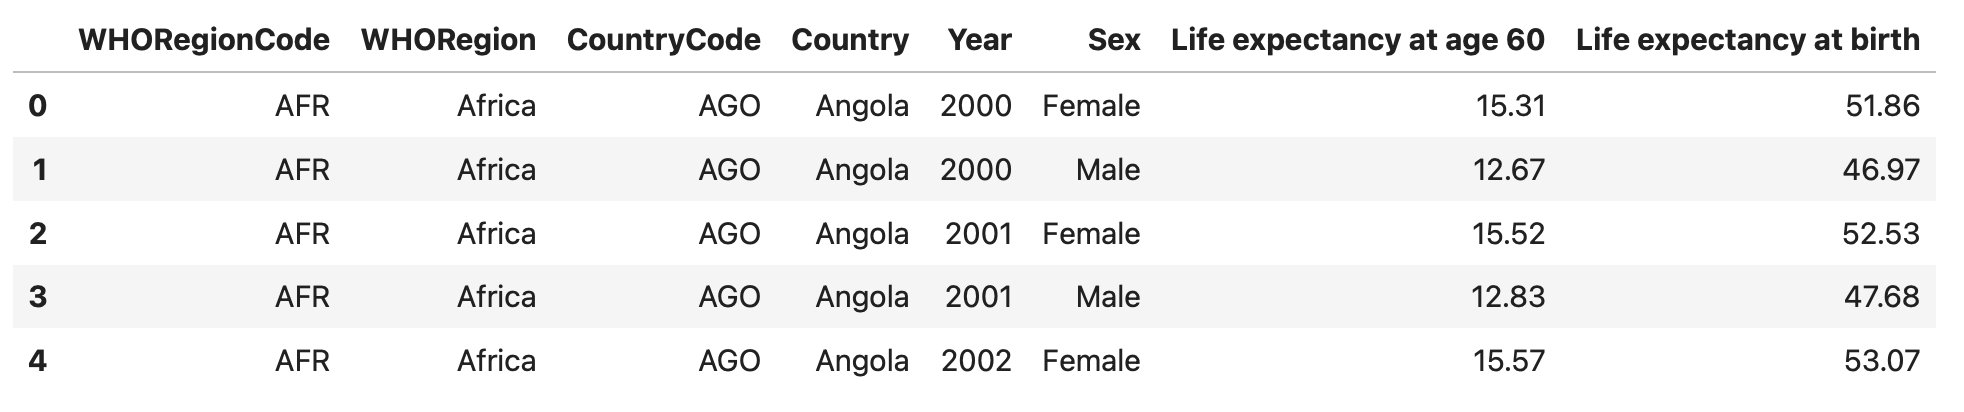

In [10]:
# === Part 1: Data Preparation – Separating Life Expectancy Indicators ===

# Make a working copy of the original dataframe
df_part1 = df.copy()

# Create the two new indicator columns based on the given assumptions
df_part1["Life expectancy at birth"] = df_part1["Life expectancy (years)"].where(
    df_part1["Life expectancy (years)"] >= 35
)

df_part1["Life expectancy at age 60"] = df_part1["Life expectancy (years)"].where(
    df_part1["Life expectancy (years)"] < 35
)

# Columns that uniquely identify each country-year-sex record
id_cols = ["WHORegionCode", "WHORegion", "CountryCode", "Country", "Year", "Sex"]

# Combine the birth and age-60 rows into one row per country-year-sex
df_separated = (
    df_part1
    .drop(columns=["Life expectancy (years)"])
    .groupby(id_cols, as_index=False)
    .agg({
        "Life expectancy at age 60": "max",
        "Life expectancy at birth": "max"
    })
)

# Arrange columns in the same format as the expected output
df_separated = df_separated[
    id_cols + ["Life expectancy at age 60", "Life expectancy at birth"]
]

# Sort the data to match the expected output order
df_separated = df_separated.sort_values(id_cols).reset_index(drop=True)

# Save the separated dataset
OUTPUT_FILE = "LifeExpectancy_separated.csv"
df_separated.to_csv(Drive_path + OUTPUT_FILE, index=False)

# Replace df with the prepared dataset for the later parts of the lab
df = df_separated.copy()

# Check the result
print(df.shape)
display(df.head())

(8140, 8)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy at age 60,Life expectancy at birth
0,AFR,Africa,AGO,Angola,2000,Female,15.31,51.86
1,AFR,Africa,AGO,Angola,2000,Male,12.67,46.97
2,AFR,Africa,AGO,Angola,2001,Female,15.52,52.53
3,AFR,Africa,AGO,Angola,2001,Male,12.83,47.68
4,AFR,Africa,AGO,Angola,2002,Female,15.57,53.07


### Part 2: Distribution Analysis [5m]
- Plot 2 histogram to show the distribution of life expectancy of both indicators, use `bins=30`.
- Compare their central tendencies (mean, median).
- Plot the boxplot of both indicators in a graph.
- List out all the outliers by country.

### Part 3: Gender-Based Analysis [5m]

- Compute average life expectancy for both indicators by sex.
- Visualize the average life expectancy of both indicators by gender with suitable plot.
- Calculate the gender gap (Female − Male) for both indicators.
- State your observation.

### Part 4: Regional Comparisons [5m]
- Compute regional averages for both indicators.
- Compare WHO regions with suitable plot.
- Identify regions with the highest and lowest life expectancy for both indicators.
- State your observation.



### Part 5: Time Trends [10m]
- Plot a life expectancy trends over time for Malaysia , Indonesia and Thailand in the same plot. (2m)
- Plot regional average life expectancy trends over time: 1 for each indicator. (2m)
- Plot a regional life expectancy at birth percentage change, and identify periods of stagnation, acceleration, or decline. (6m)

## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Submission Checklist
All submission via EbWise according to your registered group.

- [ ] Rename your Lab Exercise file according to your tutorial session and group number.
- [ ] All group members' ID, name, and contribution fill-in.
- [ ] Figures rendered and visible.
- [ ] Notebook runs top-to-bottom without errors.
